# NYSE Ratio — Advancing/Declining als Einstiegssignal in alle 4 Indizes

Dieses Notebook untersucht, ob ein **historisch besonders hoher Anteil fallender
Aktien bzw. fallenden Volumens** am Börsenplatz NYSE ein gutes Einstiegssignal
in die vier großen US-Aktienindizes gewesen wäre.

**Wichtige Unterscheidung – Börsenplatz ≠ Index.** `NYSE` ist ein
*Handelsplatz*; an ihm werden viele Aktien gehandelt. Aus den dort steigenden und
fallenden Aktien (und ihrem Volumen) bilden wir zwei Marktbreite-Kennzahlen:

- **`stocks_ratio`** = Anteil der *gestiegenen* Aktien an allen bewegten Aktien (%)
- **`volume_ratio`** = Anteil des Volumens *gestiegener* Aktien am Gesamtvolumen (%)

Ein **niedriger** Wert bedeutet: nur wenige Aktien steigen, die überwältigende
Mehrheit fällt. Die Idee dahinter ist die eines überdehnten Gummibands: Je
extremer und breiter der Ausverkauf, desto wahrscheinlicher eine Gegenbewegung
nach oben. Wir prüfen daher Tage, an denen der **Anteil fallender** Aktien/
Volumens **70 / 80 / 90 %** erreicht (gleichbedeutend mit `stocks_ratio` bzw.
`volume_ratio` **≤ 30 / 20 / 10 %**) — und zwar getrennt für **alle vier
Indizes**:

| Index | Ticker |
|---|---|
| S&P 500 | ^GSPC |
| Dow Jones | ^DJI |
| NASDAQ-100 | ^NDX |
| Russell 2000 | ^RUT |

Bewertet wird die **Vorwärtsrendite** über **30 / 60 / 90 Handelstage**, ergänzt
um **Max Drawdown** und **Sharpe Ratio**, jeweils im Vergleich zur *Basisrate*
(Durchschnitt über alle Tage). Jede Kombination aus **Index × Ratio-Typ ×
Niveau × Horizont** wird einzeln ausgewertet.

**Aufbau:**

1. Bibliotheken und Konfiguration
2. Daten laden und aufbereiten
3. Verlauf der beiden Ratios mit Einstiegs-Schwellen
4. Kreuzauswertung: Einstiegssignal je Index / Niveau / Horizont
5. Zusammenfassung


## 1. Bibliotheken und Konfiguration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display

import yfinance as yf

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.titlesize": 12,
    "font.size": 10,
    "axes.edgecolor": "#8a8a8a",
})

# Einheitliche Farben je Index (klar unterscheidbar)
INDEX_COLORS = {
    "S&P 500":      "#2a78d6",
    "Dow Jones":    "#eb6834",
    "NASDAQ-100":   "#8a3fb0",
    "Russell 2000": "#0ca30c",
}
print("Bibliotheken geladen.")

Bibliotheken geladen.


Geladen werden die Standard-Bibliotheken für Datenanalyse (`pandas`/`numpy`),
Kursdatenbezug (`yfinance`), Statistik (`scipy`) und Diagramme
(`matplotlib`/`seaborn`). Zusätzlich wird eine feste Farbe je Index festgelegt,
damit derselbe Index in allen Abbildungen dieses Notebooks gleich aussieht.


In [2]:
# --- Konfiguration -----------------------------------------------------------
VENUE = "NYSE"                      # Börsenplatz dieses Notebooks
AUSREISSER_CAP = {"NYSE": 20000, "NASDAQ": 150000}[VENUE]  # Volumen-Ausreißergrenze

AD_DIR = "Rohdaten Advancing Declining Stocks and Volume"

# Die vier Zielindizes mit ihrem Yahoo-Finance-Ticker
INDIZES = {
    "S&P 500":      "^GSPC",
    "Dow Jones":    "^DJI",
    "NASDAQ-100":   "^NDX",
    "Russell 2000": "^RUT",
}
START_DATE_DOWNLOAD = "1900-01-01"
START_DATE_ANALYSE  = "2007-01-01"

RATIO_TYPEN = ["stocks_ratio", "volume_ratio"]
NIVEAUS = [70, 80, 90]                 # Einstiegs-Schwellen in % (Anteil FALLENDER Titel/Volumens)
HORIZONTE = [30, 60, 90]               # Halteperioden in Handelstagen
MIN_SIGNALE = 30                       # ab hier gilt eine Zelle als belastbar

print(f"Börsenplatz: {VENUE}  |  Ausreißergrenze Volumen: {AUSREISSER_CAP:,}")

Börsenplatz: NYSE  |  Ausreißergrenze Volumen: 20,000


Diese Zelle enthält die einzige Stelle, die sich zwischen dem NYSE- und dem
NASDAQ-Notebook unterscheidet: den **Börsenplatz** und seine Ausreißergrenze
fürs Volumen (Tage mit unplausibel hohem gehandeltem Volumen werden später
herausgefiltert, da sie die Ratio verzerren würden). Zusätzlich werden die vier
Zielindizes, die zwei Ratio-Typen, die Schwellen (70/80/90 %, angewendet auf den
Anteil **fallender** Titel/Volumens) und die Halteperioden (30/60/90 Tage)
festgelegt. `MIN_SIGNALE = 30` markiert später, welche Auswertungen genug Fälle
haben, um belastbar zu sein.


## 2. Daten laden und aufbereiten

### 2.1 Marktbreite am Börsenplatz NYSE

In [3]:
def lade_marktbreite(venue: str, cap: int) -> pd.DataFrame:
    """Lädt die vier A/D-Rohreihen eines Börsenplatzes und bildet die Ratios."""
    def reihe(teil: str) -> pd.Series:
        roh = pd.read_csv(f"{AD_DIR}/{venue} {teil}.csv", parse_dates=["time"])
        roh = roh[roh["time"] >= pd.Timestamp("2006-12-31")]
        s = roh.set_index("time")["close"]
        s.index.name = "Date"
        return s.rename(teil.lower().replace(" ", "_"))

    df = pd.concat([reihe("Advancing Stocks"), reihe("Advancing Volume"),
                    reihe("Declining Stocks"), reihe("Declining Volume")], axis=1, sort=False)
    df = df[~df.index.duplicated(keep="first")].sort_index()
    # Volumen-Ausreißer entfernen (einmaliges Ereignis, verzerrt die Ratio)
    df = df[(df["advancing_volume"] < cap) & (df["declining_volume"] < cap)]
    df["stocks_ratio"] = df["advancing_stocks"] / (df["advancing_stocks"] + df["declining_stocks"]) * 100
    df["volume_ratio"] = df["advancing_volume"] / (df["advancing_volume"] + df["declining_volume"]) * 100
    return df.dropna(subset=["stocks_ratio", "volume_ratio"])


breite = lade_marktbreite(VENUE, AUSREISSER_CAP)
print(f"{VENUE}: {len(breite):,} Handelstage von {breite.index.min().date()} "
      f"bis {breite.index.max().date()}")
display(breite[["stocks_ratio", "volume_ratio"]].describe().round(1))

NYSE: 4,523 Handelstage von 2008-07-31 bis 2026-08-10


,stocks_ratio,volume_ratio
count,4523.0,4523.0
mean,50.9,55.7
std,21.8,21.8
min,1.1,1.0
25%,34.4,40.1
50%,51.8,57.2
75%,68.3,72.7
max,97.4,113.3


Die beiden Ratios schwanken um die 50 %: An einem normalen Tag steigt etwa die
Hälfte der Aktien/des Volumens. Werte deutlich unter 30 % (bzw. unter 20 % oder
10 %) sind also eher selten und markieren Tage mit **ungewöhnlich breitem,
extremem Ausverkauf** — genau die Tage, deren Einstiegs-Qualität wir als
Kapitulations-/Kontraindikator-Signal prüfen.


### 2.2 Kursdaten der vier Indizes und Vorwärts-Kennzahlen

In [4]:
def lade_index_daten(ticker: str, start: str) -> pd.DataFrame:
    """Lädt tägliche Schlusskurse von Yahoo Finance und bereinigt sie."""
    raw = yf.download(ticker, start=start, auto_adjust=False, actions=False, progress=False)
    if raw.empty:
        raise ValueError(f"Keine Daten für '{ticker}' erhalten - Internetverbindung prüfen.")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw.columns.name = None
    raw.index.name = "Date"
    raw = raw[~raw.index.duplicated(keep="first")].sort_index()
    raw["Close"] = raw["Close"].interpolate(method="time", limit=2)
    return raw


def forward_return(close: pd.Series, h: int) -> pd.Series:
    """Prozentuale Kursveränderung von heute bis h Handelstage später."""
    return close.shift(-h) / close - 1


def forward_max_drawdown(close: pd.Series, h: int) -> pd.Series:
    """Größter zwischenzeitlicher Rückgang vom laufenden Hoch im Fenster [t, t+h]."""
    werte = close.values
    out = np.full(len(werte), np.nan)
    for i in range(len(werte) - h):
        fenster = werte[i:i + h + 1]
        out[i] = (fenster / np.maximum.accumulate(fenster) - 1).min()
    return pd.Series(out, index=close.index)


index_daten = {}
for name, ticker in INDIZES.items():
    px = lade_index_daten(ticker, START_DATE_DOWNLOAD).loc[START_DATE_ANALYSE:][["Close"]].copy()
    for h in HORIZONTE:
        px[f"fwd_return_{h}d"] = forward_return(px["Close"], h)
        px[f"fwd_mdd_{h}d"] = forward_max_drawdown(px["Close"], h)
    index_daten[name] = px
    print(f"{name:14s}: {len(px):,} Handelstage ({px.index.min().date()} bis {px.index.max().date()})")

S&P 500       : 4,934 Handelstage (2007-01-03 bis 2026-08-18)


Dow Jones     : 4,934 Handelstage (2007-01-03 bis 2026-08-18)


NASDAQ-100    : 4,934 Handelstage (2007-01-03 bis 2026-08-18)


Russell 2000  : 4,934 Handelstage (2007-01-03 bis 2026-08-18)


Für jeden der vier Indizes werden die täglichen Schlusskurse geladen; daraus
berechnen wir zwei Vorwärts-Kennzahlen für jede der drei Halteperioden: die
**Rendite** (Kursveränderung von heute bis h Tage später) und den **Max
Drawdown** (größter zwischenzeitlicher Rückgang innerhalb dieses Zeitfensters).
Diese beiden Kennzahlen bilden die Grundlage für alle folgenden Auswertungen.


### 2.3 Signal-Kalender mit Index-Kennzahlen verknüpfen

In [5]:
# Je Index: Marktbreite (Börsenplatz-Kalender) mit den Vorwärts-Kennzahlen des
# Index verbinden. Beide teilen den US-Handelskalender, daher inner join per Datum.
merged = {}
for name, px in index_daten.items():
    m = breite[["stocks_ratio", "volume_ratio"]].join(
        px[["Close"] + [f"fwd_return_{h}d" for h in HORIZONTE]
                     + [f"fwd_mdd_{h}d" for h in HORIZONTE]], how="inner")
    merged[name] = m
    print(f"{name:14s}: {len(m):,} gemeinsame Handelstage")

S&P 500       : 4,520 gemeinsame Handelstage
Dow Jones     : 4,520 gemeinsame Handelstage
NASDAQ-100    : 4,520 gemeinsame Handelstage
Russell 2000  : 4,520 gemeinsame Handelstage


Das Signal entsteht am Börsenplatz (z. B. „70 % der Aktien gefallen"), die
Wirkung wird aber am jeweiligen **Index** gemessen. Deshalb werden beide über
das Datum zusammengeführt, sodass sich für jeden Signaltag die anschließende
Index-Entwicklung auswerten lässt.


## 3. Verlauf der beiden Ratios mit Einstiegs-Schwellen

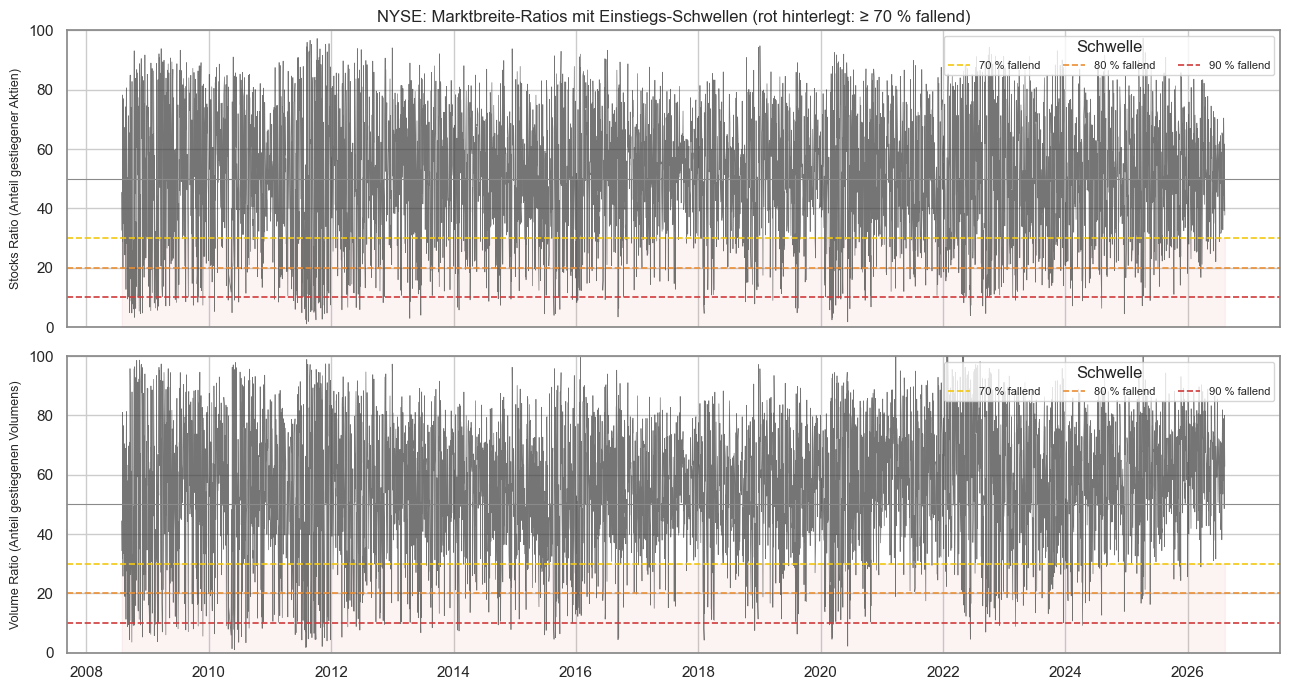

In [6]:
fig, achsen = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for achse, ratio, titel in zip(achsen, RATIO_TYPEN,
                               ["Stocks Ratio (Anteil gestiegener Aktien)",
                                "Volume Ratio (Anteil gestiegenen Volumens)"]):
    achse.plot(breite.index, breite[ratio], color="#3a3a3a", linewidth=0.5, alpha=0.7)
    for niv, farbe in zip(NIVEAUS, ["#f2c811", "#eb8f34", "#d03b3b"]):
        achse.axhline(100 - niv, color=farbe, linestyle="--", linewidth=1.2, label=f"{niv} % fallend")
    achse.axhline(50, color="#8a8a8a", linewidth=0.8)
    achse.fill_between(breite.index, 0, 30, color="#d03b3b", alpha=0.06)
    achse.set_ylabel(titel, fontsize=9)
    achse.set_ylim(0, 100)
    achse.legend(loc="upper right", ncol=3, fontsize=8, title="Schwelle")
achsen[0].set_title(f"{VENUE}: Marktbreite-Ratios mit Einstiegs-Schwellen (rot hinterlegt: ≥ 70 % fallend)")
fig.tight_layout()
plt.show()

Jede Linie zeigt den Tagesverlauf einer Ratio (Anteil *steigender* Titel/
Volumens); die gestrichelten Linien markieren die Einstiegs-Schwellen, aber auf
der Skala des Anteils fallender Titel — die 70-%-Schwelle für "fallend" liegt
also bei 30 % auf dieser Skala (100 − 70), die 90-%-Schwelle bei 10 %. Der rot
hinterlegte Bereich (≤ 30 %, entspricht ≥ 70 % fallend) markiert die
Einstiegs-Tage. Solche extremen Ausverkäufe treten gehäuft **während** starker
Markteinbrüche auf — die entscheidende Frage ist, ob sie eine baldige Erholung
ankündigen oder der Kurs zunächst weiter fällt.


## 4. Kreuzauswertung: Einstiegssignal je Index / Niveau / Horizont

In [7]:
def sharpe_horizont(renditen: pd.Series, h: int) -> float:
    """Näherungsweise annualisierte Sharpe Ratio aus h-Tage-Vorwärtsrenditen (rf=0).
    Die Fenster überlappen sich (nicht unabhängig) – als Orientierungswert lesen."""
    r = renditen.dropna()
    if len(r) < 2 or r.std() == 0:
        return np.nan
    return r.mean() / r.std() * np.sqrt(252 / h)


def vergleiche_gruppen(a: pd.Series, b: pd.Series) -> float:
    """p-Wert aus t-Test UND Mann-Whitney-U-Test; liefert den größeren (strengeren)
    der beiden p-Werte zurück, damit ein Signal nur als signifikant gilt, wenn es
    beide Tests besteht."""
    a, b = a.dropna(), b.dropna()
    if len(a) < 3 or len(b) < 3:
        return np.nan
    _, t_p = stats.ttest_ind(a, b, equal_var=False)
    _, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return max(t_p, u_p)


zeilen = []
for index_name, m in merged.items():
    for ratio in RATIO_TYPEN:
        for niveau in NIVEAUS:
            signal = m[ratio] <= (100 - niveau)
            for h in HORIZONTE:
                fr_sig = m.loc[signal, f"fwd_return_{h}d"].dropna()
                fr_all = m[f"fwd_return_{h}d"].dropna()
                md_sig = m.loc[signal, f"fwd_mdd_{h}d"].dropna()
                n = len(fr_sig)
                p = vergleiche_gruppen(fr_sig, fr_all) if n >= 3 else np.nan
                zeilen.append({
                    "Index": index_name, "Ratio": ratio, "Niveau": niveau, "Horizont": h,
                    "n": n,
                    "Rendite_Signal": fr_sig.mean() if n else np.nan,
                    "Rendite_Basis": fr_all.mean(),
                    "Mehrrendite": (fr_sig.mean() - fr_all.mean()) if n else np.nan,
                    "MaxDD_Signal": md_sig.mean() if n else np.nan,
                    "MaxDD_Basis": m[f"fwd_mdd_{h}d"].mean(),
                    "Sharpe_Signal": sharpe_horizont(fr_sig, h),
                    "Sharpe_Basis": sharpe_horizont(fr_all, h),
                    "p_Wert": p,
                    "belastbar": n >= MIN_SIGNALE,
                })

ergebnis = pd.DataFrame(zeilen)
print(f"{len(ergebnis)} Kombinationen (4 Indizes x 2 Ratios x 3 Niveaus x 3 Horizonte)")
print(f"davon belastbar (n >= {MIN_SIGNALE}): {int(ergebnis['belastbar'].sum())}")

72 Kombinationen (4 Indizes x 2 Ratios x 3 Niveaus x 3 Horizonte)
davon belastbar (n >= 30): 72


Das ist das Herzstück der Auswertung: Für **jede** Kombination aus Index,
Ratio-Typ, Schwelle (70/80/90 % fallend) und Horizont (30/60/90 Tage) wird die
durchschnittliche Rendite nach dem Signal berechnet, die **Mehrrendite**
gegenüber der Basisrate (alle Tage), der Max Drawdown, die Sharpe Ratio und ein
p-Wert. Ein Ergebnis gilt hier als statistisch signifikant, wenn **sowohl** ein
t-Test **als auch** ein Mann-Whitney-U-Test den Renditeunterschied bestätigen
(der strengere der beiden p-Werte wird berichtet) — derselbe, bewusst strenge
Maßstab wie im übrigen Projekt. Insgesamt 72 Kombinationen je Börsenplatz.


In [8]:
# Übersichtstabelle (formatiert). "belastbar" = mindestens 30 Signaltage.
anzeige = ergebnis.copy()
for spalte in ["Rendite_Signal", "Rendite_Basis", "Mehrrendite", "MaxDD_Signal", "MaxDD_Basis"]:
    anzeige[spalte] = anzeige[spalte].map(lambda x: f"{x:+.1%}" if pd.notna(x) else "—")
for spalte in ["Sharpe_Signal", "Sharpe_Basis"]:
    anzeige[spalte] = anzeige[spalte].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
anzeige["p_Wert"] = anzeige["p_Wert"].map(lambda x: ("<0,001" if x < 0.001 else f"{x:.3f}") if pd.notna(x) else "—")
anzeige["belastbar"] = anzeige["belastbar"].map(lambda x: "ja" if x else "nein")
display(anzeige)

,Index,Ratio,Niveau,Horizont,n,Rendite_Signal,Rendite_Basis,Mehrrendite,MaxDD_Signal,MaxDD_Basis,Sharpe_Signal,Sharpe_Basis,p_Wert,belastbar
0,S&P 500,stocks_ratio,70,30,893,+1.8%,+1.4%,+0.4%,-6.0%,-5.1%,0.78,0.71,0.079,ja
1,S&P 500,stocks_ratio,70,60,891,+3.5%,+2.8%,+0.7%,-8.2%,-7.3%,0.86,0.77,0.019,ja
2,S&P 500,stocks_ratio,70,90,887,+5.4%,+4.4%,+1.0%,-9.6%,-8.9%,0.91,0.85,0.006,ja
3,S&P 500,stocks_ratio,80,30,446,+1.8%,+1.4%,+0.5%,-6.8%,-5.1%,0.72,0.71,0.202,ja
4,S&P 500,stocks_ratio,80,60,446,+4.1%,+2.8%,+1.2%,-8.8%,-7.3%,0.95,0.77,0.004,ja
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Russell 2000,volume_ratio,80,60,320,+5.0%,+2.6%,+2.4%,-11.8%,-10.1%,0.83,0.51,"<0,001",ja
68,Russell 2000,volume_ratio,80,90,320,+7.4%,+4.0%,+3.3%,-13.2%,-12.1%,0.87,0.55,"<0,001",ja
69,Russell 2000,volume_ratio,90,30,96,+1.4%,+1.3%,+0.1%,-10.9%,-7.0%,0.34,0.48,0.929,ja
70,Russell 2000,volume_ratio,90,60,96,+5.0%,+2.6%,+2.4%,-14.3%,-10.1%,0.74,0.51,0.097,ja


Eine positive **Mehrrendite** bedeutet: Nach dem Signal (extremer Ausverkauf)
lief der Index besser als im Durchschnitt — ein Hinweis darauf, dass sich das
"überdehnte Gummiband" tatsächlich löst und der Markt sich erholt. Die Spalte
**belastbar** kennzeichnet zu wenige Signaltage (v. a. beim seltenen
90-%-Niveau): Solche Werte sind interessant, aber statistisch unsicher und
nicht überzubewerten.


### 4.1 Grafik 1 – Heatmap der Mehrrendite (Überblick)

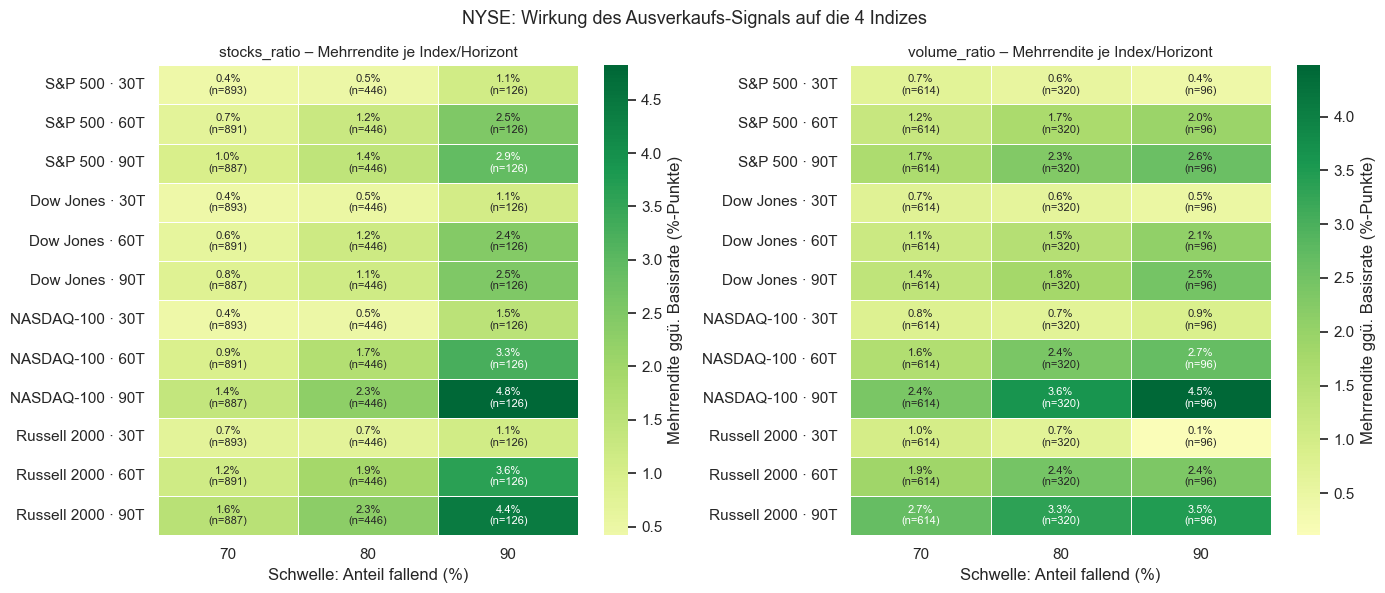

In [9]:
fig, achsen = plt.subplots(1, 2, figsize=(14, 6))
for achse, ratio in zip(achsen, RATIO_TYPEN):
    teil = ergebnis[ergebnis["Ratio"] == ratio].copy()
    teil["Zeile"] = teil["Index"] + " · " + teil["Horizont"].astype(str) + "T"
    pivot = teil.pivot(index="Zeile", columns="Niveau", values="Mehrrendite") * 100
    reihenfolge = [f"{ix} · {h}T" for ix in INDIZES for h in HORIZONTE]
    pivot = pivot.reindex(reihenfolge)
    n_pivot = teil.pivot(index="Zeile", columns="Niveau", values="n").reindex(reihenfolge)
    annot = pivot.round(1).astype(str) + "%\n(n=" + n_pivot.astype(int).astype(str) + ")"
    sns.heatmap(pivot, ax=achse, cmap="RdYlGn", center=0, annot=annot, fmt="",
                annot_kws={"fontsize": 8}, linewidths=0.6, linecolor="white",
                cbar_kws={"label": "Mehrrendite ggü. Basisrate (%-Punkte)"})
    achse.set_title(f"{ratio} – Mehrrendite je Index/Horizont", fontsize=11)
    achse.set_xlabel("Schwelle: Anteil fallend (%)")
    achse.set_ylabel("")
fig.suptitle(f"{VENUE}: Wirkung des Ausverkaufs-Signals auf die 4 Indizes", fontsize=13)
fig.tight_layout()
plt.show()

Jede Zelle ist eine Kombination aus Index und Horizont (Zeile) und Schwelle
(Spalte). **Grün = Mehrrendite** (Signal besser als der Durchschnitt), **Rot =
Minderrendite**. In Klammern steht die Zahl der Signaltage (n). Die Heatmap
zeigt auf einen Blick, in welchem Index und bei welcher Schwelle das
Kapitulations-Signal am ehesten eine anschließende Erholung anzeigt — und wo
die Datenbasis dünn ist.


### 4.2 Grafik 2 – Uplift-Balken je Index und Niveau (90-Tage-Horizont)

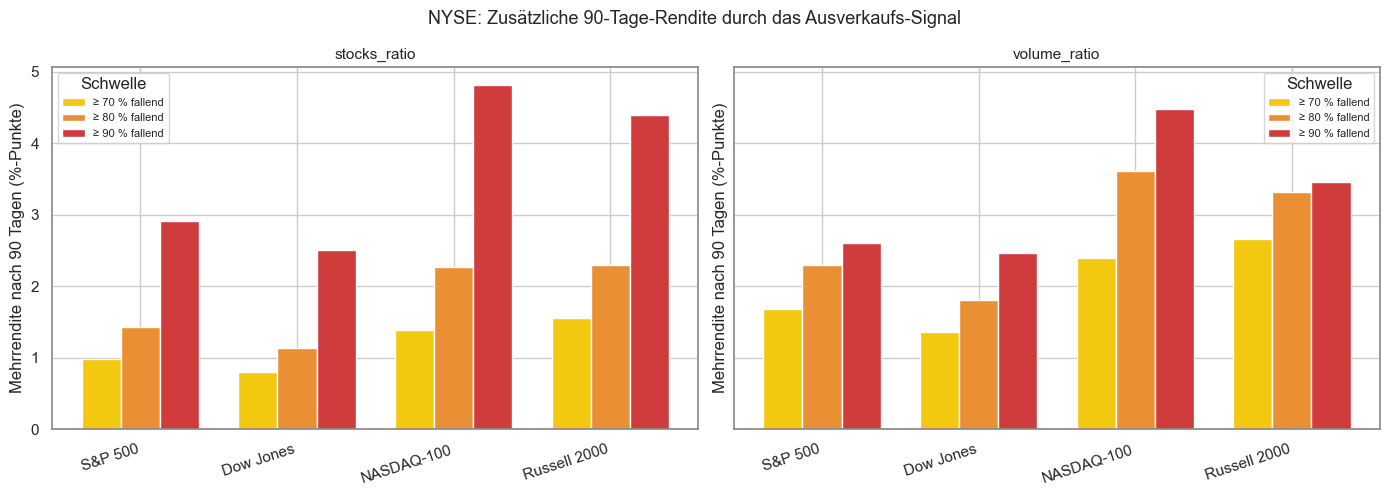

In [10]:
H_PLOT = 90
fig, achsen = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for achse, ratio in zip(achsen, RATIO_TYPEN):
    teil = ergebnis[(ergebnis["Ratio"] == ratio) & (ergebnis["Horizont"] == H_PLOT)]
    x = np.arange(len(INDIZES))
    breite_bar = 0.25
    for i, niv in enumerate(NIVEAUS):
        werte = [teil[(teil["Index"] == ix) & (teil["Niveau"] == niv)]["Mehrrendite"].values[0] * 100
                 for ix in INDIZES]
        achse.bar(x + (i - 1) * breite_bar, werte, breite_bar, label=f"≥ {niv} % fallend",
                  color=["#f2c811", "#eb8f34", "#d03b3b"][i])
    achse.axhline(0, color="#333", linewidth=0.8)
    achse.set_xticks(x)
    achse.set_xticklabels(list(INDIZES), rotation=18, ha="right")
    achse.set_title(f"{ratio}", fontsize=11)
    achse.set_ylabel(f"Mehrrendite nach {H_PLOT} Tagen (%-Punkte)")
    achse.legend(title="Schwelle", fontsize=8)
fig.suptitle(f"{VENUE}: Zusätzliche {H_PLOT}-Tage-Rendite durch das Ausverkaufs-Signal", fontsize=13)
fig.tight_layout()
plt.show()

Balken über null bedeuten: Der Einstieg nach dem Ausverkaufs-Signal hätte über
90 Tage **mehr** Rendite gebracht als ein beliebiger Tag. Strengere Schwellen
(rot, ≥ 90 % fallend) sind selektiver — oft mit größerem Ausschlag, aber auch
weniger Fällen. Der Vergleich der vier Indizes zeigt, wo das Signal des
Börsenplatzes am stärksten wirkt.


### 4.3 Grafik 3 – Verteilung der 90-Tage-Renditen (Signal vs. alle Tage)

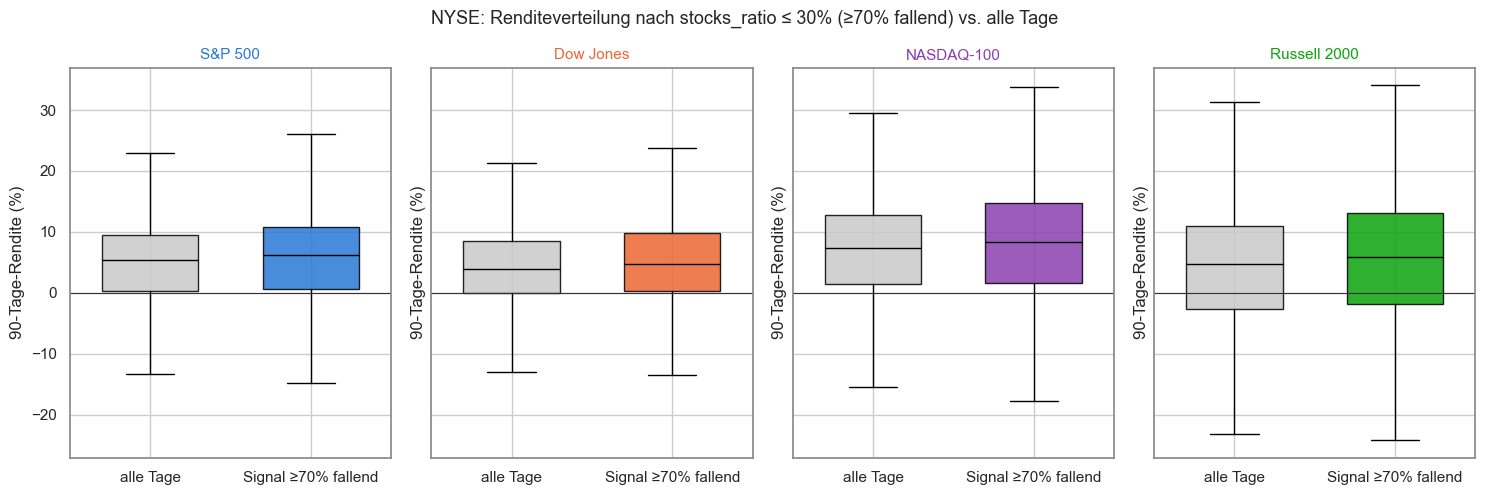

In [11]:
RATIO_BOX, NIVEAU_BOX, H_BOX = "stocks_ratio", 70, 90
fig, achsen = plt.subplots(1, 4, figsize=(15, 5), sharey=True)
for achse, (name, m) in zip(achsen, merged.items()):
    signal = m[RATIO_BOX] <= (100 - NIVEAU_BOX)
    daten = [m[f"fwd_return_{H_BOX}d"].dropna() * 100,
             m.loc[signal, f"fwd_return_{H_BOX}d"].dropna() * 100]
    bp = achse.boxplot(daten, tick_labels=["alle Tage", f"Signal ≥{NIVEAU_BOX}% fallend"],
                       patch_artist=True, widths=0.6, showfliers=False)
    for patch, farbe in zip(bp["boxes"], ["#c9c9c9", INDEX_COLORS[name]]):
        patch.set_facecolor(farbe)
        patch.set_alpha(0.85)
    for med in bp["medians"]:
        med.set_color("black")
    achse.axhline(0, color="#333", linewidth=0.8)
    achse.set_title(name, fontsize=11, color=INDEX_COLORS[name])
    achse.set_ylabel(f"{H_BOX}-Tage-Rendite (%)")
fig.suptitle(f"{VENUE}: Renditeverteilung nach {RATIO_BOX} \u2264 {100-NIVEAU_BOX}% (\u2265{NIVEAU_BOX}% fallend) vs. alle Tage", fontsize=13)
fig.tight_layout()
plt.show()

Die Box zeigt die mittleren 50 % der Renditen, der Strich in der Box den
Median. Liegt die Signal-Box **höher** als die „alle Tage"-Box, war das Signal
im Schnitt besser. Boxplots zeigen zugleich die **Streuung** — ein höherer
Mittelwert nützt wenig, wenn die Spanne riesig ist. So wird sichtbar, wie
verlässlich der Vorteil tatsächlich ist; gerade bei einem Kapitulationssignal
ist mit größerer Streuung zu rechnen, da starke Ausverkäufe sich nicht immer
sofort erholen.


### 4.4 Grafik 4 – Event-Study: mittlerer Kursverlauf nach dem Signal

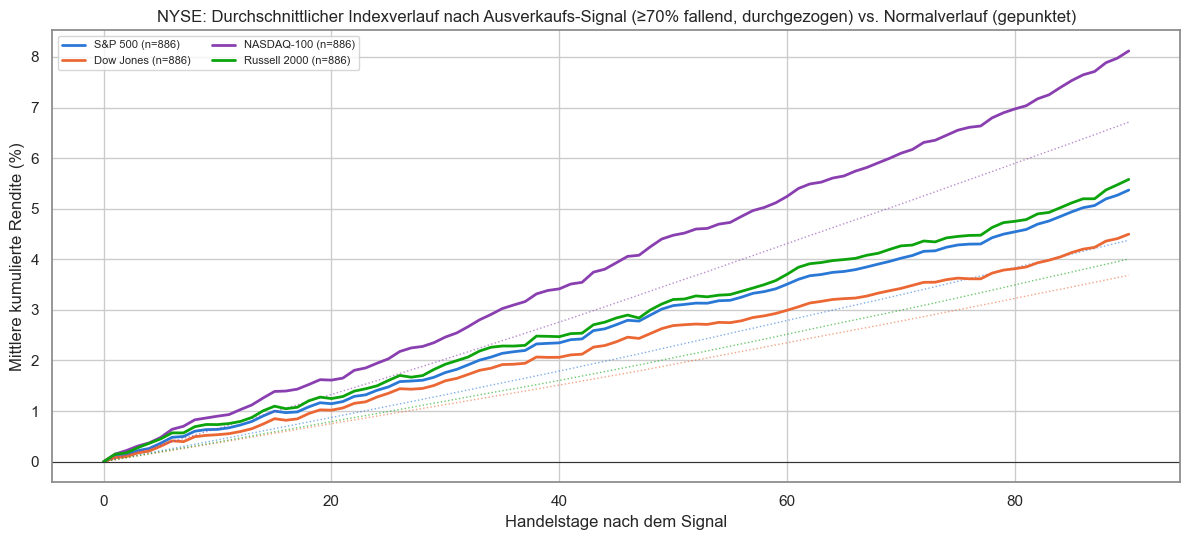

In [12]:
RATIO_EV, NIVEAU_EV, TAGE_EV = "stocks_ratio", 70, 90
fig, achse = plt.subplots(figsize=(12, 5.5))
for name, m in merged.items():
    close = m["Close"].values
    signal_idx = np.where((m[RATIO_EV] <= (100 - NIVEAU_EV)).values)[0]
    pfade = [close[i:i + TAGE_EV + 1] / close[i] - 1
             for i in signal_idx if i + TAGE_EV < len(close)]
    if pfade:
        mittel = np.mean(pfade, axis=0) * 100
        achse.plot(range(TAGE_EV + 1), mittel, color=INDEX_COLORS[name], linewidth=2,
                   label=f"{name} (n={len(pfade)})")
    # Basisrate: mittlere Kursentwicklung über ALLE Starttage
    basis = [close[i:i + TAGE_EV + 1] / close[i] - 1 for i in range(len(close) - TAGE_EV)]
    achse.plot(range(TAGE_EV + 1), np.mean(basis, axis=0) * 100,
               color=INDEX_COLORS[name], linewidth=1, linestyle=":", alpha=0.6)
achse.axhline(0, color="#333", linewidth=0.8)
achse.set_xlabel("Handelstage nach dem Signal")
achse.set_ylabel("Mittlere kumulierte Rendite (%)")
achse.set_title(f"{VENUE}: Durchschnittlicher Indexverlauf nach Ausverkaufs-Signal (\u2265{NIVEAU_EV}% fallend, "
                f"durchgezogen) vs. Normalverlauf (gepunktet)")
achse.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

Jede durchgezogene Linie zeigt den **gemittelten Kursverlauf** in den 90 Tagen
nach einem Ausverkaufs-Signal (Start = 0 %); die gepunktete Linie derselben
Farbe zeigt den Normalverlauf des Index über alle Tage. Liegt die
durchgezogene Linie über der gepunkteten, hat sich der Index nach dem Signal
überdurchschnittlich entwickelt — erkennbar ist zudem, **ab wann** der
vermutete Erholungseffekt einsetzt (oder ob der Kurs zunächst noch weiter
fällt, bevor er sich erholt).


## 5. Zusammenfassung


In [13]:
bel = ergebnis[ergebnis["belastbar"]].copy()
positiv = bel[bel["Mehrrendite"] > 0]
anteil_positiv = len(positiv) / len(bel) if len(bel) else float("nan")
signifikant = bel[(bel["Mehrrendite"] > 0) & (bel["p_Wert"] < 0.05)]

print(f"Börsenplatz {VENUE} — belastbare Kombinationen: {len(bel)} von {len(ergebnis)}")
print(f"  davon mit positiver Mehrrendite: {len(positiv)} ({anteil_positiv:.0%})")
print(f"  davon zusätzlich statistisch signifikant (p<0,05): {len(signifikant)}")
print()
print("Stärkste belastbare Signale (nach Mehrrendite):")
top = bel.sort_values("Mehrrendite", ascending=False).head(5)
for _, r in top.iterrows():
    stern = "*" if r["p_Wert"] < 0.05 else " "
    print(f"  {stern} {r['Index']:14s} | {r['Ratio']:12s} \u2265{r['Niveau']}% fallend | {r['Horizont']}T: "
          f"{r['Mehrrendite']:+.1%} (Signal {r['Rendite_Signal']:+.1%} vs. Basis {r['Rendite_Basis']:+.1%}, "
          f"Sharpe {r['Sharpe_Signal']:.2f} vs. {r['Sharpe_Basis']:.2f}, n={r['n']})")
print("\n  * = statistisch signifikant (p<0,05)")

Börsenplatz NYSE — belastbare Kombinationen: 72 von 72
  davon mit positiver Mehrrendite: 72 (100%)
  davon zusätzlich statistisch signifikant (p<0,05): 52

Stärkste belastbare Signale (nach Mehrrendite):
  * NASDAQ-100     | stocks_ratio ≥90% fallend | 90T: +4.8% (Signal +11.6% vs. Basis +6.7%, Sharpe 1.31 vs. 1.06, n=126)
  * NASDAQ-100     | volume_ratio ≥90% fallend | 90T: +4.5% (Signal +11.2% vs. Basis +6.7%, Sharpe 1.34 vs. 1.06, n=96)
  * Russell 2000   | stocks_ratio ≥90% fallend | 90T: +4.4% (Signal +8.4% vs. Basis +4.0%, Sharpe 0.84 vs. 0.55, n=126)
  * Russell 2000   | stocks_ratio ≥90% fallend | 60T: +3.6% (Signal +6.2% vs. Basis +2.6%, Sharpe 0.87 vs. 0.51, n=126)
  * NASDAQ-100     | volume_ratio ≥80% fallend | 90T: +3.6% (Signal +10.3% vs. Basis +6.7%, Sharpe 1.38 vs. 1.06, n=320)

  * = statistisch signifikant (p<0,05)


**Fazit für NYSE (dynamisch aus den Zahlen oben).** Der Ausdruck zeigt,
für wie viele der belastbaren Kombinationen das Kapitulations-Signal eine
**positive Mehrrendite** gebracht hätte, und welche davon zusätzlich statistisch
signifikant sind. Als Faustregel gilt: Ein extremer, breiter Ausverkauf am
Börsenplatz NYSE ist dann ein brauchbares Einstiegssignal, wenn die
Mehrrendite **über mehrere Indizes, Niveaus und Horizonte hinweg** positiv ist —
Einzeltreffer bei seltenen 90-%-Signalen (kleines n) sollten dagegen vorsichtig
interpretiert werden.

**Grenzen der Analyse.** Es handelt sich um eine **explorative** Auswertung
historischer Durchschnitte ohne Transaktionskosten; überlappende Zeitfenster
machen die p-Werte zu Orientierungswerten, nicht zu exakten Wahrscheinlichkeiten.
Die Ergebnisse sind ein Anhaltspunkt, keine Handelsgarantie.